In [1]:
print("Fake Job Detection Project Started")

Fake Job Detection Project Started


In [2]:
#!pip install numpy pandas matplotlib seaborn scikit-learn nltk joblib

In [3]:
import pandas as pd

df = pd.read_csv("../data/fake_job_postings.csv", encoding="latin1")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI â Environmental Systems Re...,"EDUCATION:Â Bachelorâs or Masterâs in GIS,...",Our culture is anything but corporateâwe hav...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.shape

(17880, 18)

In [5]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [6]:
df['text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('')
)

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['clean_text'])
y = df['fraudulent']

In [9]:
from sklearn.feature_selection import SelectKBest, chi2

In [10]:
selector = SelectKBest(chi2, k=2000)

X_selected = selector.fit_transform(X, y)

print("Original features:", X.shape)
print("Selected features:", X_selected.shape)

Original features: (17880, 5000)
Selected features: (17880, 2000)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_sm, y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = rf_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9793064876957495
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.91      0.65      0.76       181

    accuracy                           0.98      3576
   macro avg       0.95      0.82      0.88      3576
weighted avg       0.98      0.98      0.98      3576



In [15]:
import joblib

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(selector, "../models/feature_selector.pkl")
joblib.dump(rf_smote, "../models/fake_job_rf_smote_model.pkl")

['../models/fake_job_rf_smote_model.pkl']

In [16]:
!pip install streamlit

In [17]:
!streamlit --version

Streamlit, version 1.51.0


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9711968680089486
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3395
           1       0.99      0.44      0.61       181

    accuracy                           0.97      3576
   macro avg       0.98      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



In [21]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: fraudulent
0    13619
1      685
Name: count, dtype: int64
After SMOTE: fraudulent
0    13619
1    13619
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_sm, y_train_sm)

y_pred_rf_smote = rf_smote.predict(X_test)

print("Random Forest + SMOTE Accuracy:",
      accuracy_score(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))

Random Forest + SMOTE Accuracy: 0.9812639821029083
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.99      0.64      0.77       181

    accuracy                           0.98      3576
   macro avg       0.99      0.82      0.88      3576
weighted avg       0.98      0.98      0.98      3576



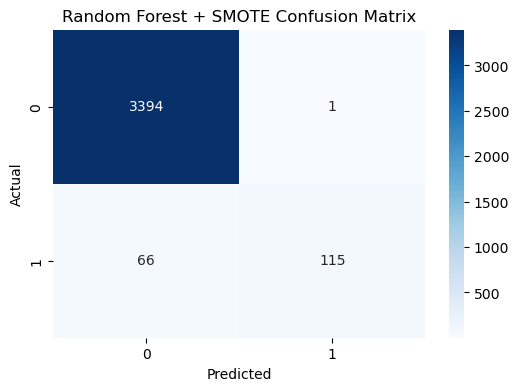

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf_smote)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest + SMOTE Confusion Matrix")

plt.savefig("confusion_matrix.png")  # 👈 SAVES IMAGE
plt.show()

In [26]:
import joblib

joblib.dump(rf_smote, "../models/fake_job_rf_smote_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']